# Eval Classification Light

Only the **TPR @ fixed FPR** plots used in the rightmost column of `Eval_Classification.ipynb`:
- CC1$\pi^\pm$: side-by-side $E_\pi$ and $\theta_\pi$
- CC$\pi^0$: side-by-side $E_\pi$ and $\theta_\pi$
- CCN$\pi$: single $q_3$ plot


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
if str(ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(ROOT / "notebooks"))

from eval_classification_plots import (
    load_results,
    load_truth_and_baselines,
    data_with_signal_pion_bins,
    mc_value_in_bin,
    compute_all_metrics,
    compute_all_metrics_q3,
    compute_reco_baseline_recall_per_bin,
    _plot_metric_line,
    save_figures_to_pdf,
)
from src.utils.utils import get_classification_runs_by_model_and_cap

CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")
OUTPUT_DIR = ROOT / "out" / "classification_eval_light"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WANDB_TAG = "Run_2703"
PLAYLISTS = ["1A", "1B"]

clrs_dict_full = {
    "Transformer": "#1f77b4",
    "Transformer-xsmall": "#1f77b4",
    "OmniLearned-small": "#ff7f0e",
    "OmniLearned-small-int": "#66c2a5",
    "Transformer-small": "#17becf",
    "MLP": "#2ca02c",
    "OmniLearned-medium": "#9467bd",
    "OmniLearned-small-rw": "#e377c2",
    "Transformer2": "#d62728",
}

runs_by_model_cap = get_classification_runs_by_model_and_cap(WANDB_TAG)
training_names = {key: value[-1] for key, value in runs_by_model_cap.items()}

results = load_results(CKPT_DIR, training_names, playlists=PLAYLISTS)
data_by_playlist = {
    pl: load_truth_and_baselines(CKPT_DIR, training_names, playlists=[pl])
    for pl in PLAYLISTS
}


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /global/homes/g/gregork/.netrc.


Calling wandb API...


  Fetching runs from fcc_ml/minerva-models with tag 'Run_2703'...


  Wandb API finished: 76 run(s) found with tag 'Run_2703'.


[MLP] loaded 4 run(s)


[OmniLearned-medium] loaded 2 run(s)


[OmniLearned-small] loaded 4 run(s)


[OmniLearned-small-rw] loaded 4 run(s)


[Transformer-small] loaded 4 run(s)


[Transformer-xsmall] loaded 6 run(s)


In [2]:
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma

# Unified style for all binned count / S/B figures
COLOR_N_TOTAL = "#9e9e9e"
COLOR_N_SIGNAL = "#1f77b4"
COLOR_SB = "#2ca02c"
HIST_EDGE = "0.25"
HIST_EDGELINE = 0.35
HIST_ALPHA_TOTAL = 0.55
HIST_ALPHA_SIGNAL = 0.9


def _legend_title_playlist_task(_playlist: str, task_line2: str) -> str:
    return f"Minerva Open Data Playlist 1A/1B\n{task_line2}"


def _apply_legend_title(ax, leg_title: str) -> None:
    leg = ax.legend(fontsize=7, title=leg_title)
    if leg.get_title() is not None:
        leg.get_title().set_fontsize(8)


def per_bin_total_and_signal(
    y_true_signal: np.ndarray,
    bin_var: np.ndarray,
    bin_edges: np.ndarray,
    has_pion: np.ndarray | None = None,
    require_finite_bin_var: bool = False,
) -> Tuple[np.ndarray, np.ndarray]:
    """Per-bin counts: events in (edge_i, edge_{i+1}] vs signal in that bin.

    *y_true_signal* is a boolean (or 0/1) mask: True = signal for this task.
    Background per bin is *n_tot - n_sig* (all non-signal events in the bin).

    When *has_pion* is None, no ``has_pion`` cut is applied (full sample in bins).
    For :math:`\\theta_\\pi`, set ``require_finite_bin_var=True`` so binning matches
    ``eval_classification_plots`` with ``pion_bins_require_has_pion=False``.
    """
    n_tot, n_sig = [], []
    for i in range(len(bin_edges) - 1):
        bm = mc_value_in_bin(
            bin_var, bin_edges, i, require_finite=require_finite_bin_var
        )
        if has_pion is not None:
            bm = bm & has_pion
        n_tot.append(int(bm.sum()))
        n_sig.append(int((bm & y_true_signal).sum()))
    return np.array(n_tot), np.array(n_sig)


def sb_ratio(n_tot: np.ndarray, n_sig: np.ndarray) -> np.ndarray:
    n_bg = n_tot - n_sig
    return np.divide(
        n_sig, n_bg, out=np.full_like(n_sig, np.nan, dtype=float), where=n_bg > 0
    )


def sb_ratio_vs_global_bkg(n_sig: np.ndarray, n_bg_global: int) -> np.ndarray:
    """S/B with ROC denominator: all non-signal events (same count every bin)."""
    if n_bg_global <= 0:
        return np.full_like(n_sig, np.nan, dtype=float)
    return np.asarray(n_sig, dtype=float) / float(n_bg_global)


def plot_histogram_counts(
    ax: plt.Axes,
    bin_edges: np.ndarray,
    n_tot: np.ndarray,
    n_sig: np.ndarray,
    xlabel: str,
    log_x: bool = False,
    leg_title: str | None = None,
    n_bg_global: int | None = None,
) -> None:
    """Gray = all events in kinematic bin; blue = signal in bin; dashed = global N_bkg (ROC)."""
    edges = np.asarray(bin_edges, dtype=float)
    w = np.diff(edges)
    x0 = edges[:-1]
    ax.bar(
        x0,
        n_tot,
        width=w,
        align="edge",
        color=COLOR_N_TOTAL,
        alpha=HIST_ALPHA_TOTAL,
        edgecolor=HIST_EDGE,
        linewidth=HIST_EDGELINE,
        label=r"$N_{\mathrm{in\,bin}}$ (all classes)",
    )
    ax.bar(
        x0,
        n_sig,
        width=w,
        align="edge",
        color=COLOR_N_SIGNAL,
        alpha=HIST_ALPHA_SIGNAL,
        edgecolor=HIST_EDGE,
        linewidth=HIST_EDGELINE,
        label=r"$N_{\mathrm{signal\,in\,bin}}$",
    )
    if n_bg_global is not None and n_bg_global > 0:
        ax.axhline(
            n_bg_global,
            color="#424242",
            linestyle="--",
            linewidth=1.4,
            label=rf"$N_{{\mathrm{{bkg}}}}^{{\mathrm{{glob}}}} = {n_bg_global}$ (ROC negatives)",
        )
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Events per bin")
    ax.set_title(r"Kinematic bin counts (ROC uses global $N_{\mathrm{bkg}}$)")
    ax.grid(True, axis="y", alpha=0.35)
    if leg_title is not None:
        _apply_legend_title(ax, leg_title)


def plot_sb_stairs(
    ax,
    bin_edges: np.ndarray,
    sb: np.ndarray,
    xlabel: str,
    log_x: bool = False,
    leg_title: str | None = None,
    y_title: str | None = None,
) -> None:
    """S/B stairs; *y_title* names the background denominator."""
    edges = np.asarray(bin_edges, dtype=float)
    sb = np.asarray(sb, dtype=float)
    sb_plot = ma.masked_invalid(sb)
    ax.stairs(sb_plot, edges, color=COLOR_SB, linewidth=1.6, label=r"$S/B$")
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"Signal / background ($S/B$)")
    if y_title is None:
        y_title = r"$S/B$ ($B = N_{\mathrm{in\,bin}} - N_{\mathrm{signal}}$)"
    ax.set_title(y_title)
    ax.grid(True, alpha=0.35)
    if leg_title is not None:
        _apply_legend_title(ax, leg_title)


def plot_tpr_fixed_fpr_two_panel(
    metrics,
    x_left,
    x_right,
    left_key,
    right_key,
    fixed_fpr,
    x_label_left,
    x_label_right,
    reco_baseline_tpr,
    reco_label,
    title,
    playlist: str,
    task_legend_line2: str,
    log_x_left=False,
    colors=None,
):
    """One row, two columns: TPR @ fixed FPR only."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), tight_layout=True)
    ax_l, ax_r = axes[0], axes[1]
    leg_title = _legend_title_playlist_task(playlist, task_legend_line2)

    for model_name, model_metrics in metrics.items():
        clr = {} if colors is None else {"color": colors.get(model_name)}
        for fpr_val in fixed_fpr:
            key = f"tpr@{fpr_val}"
            _plot_metric_line(
                ax_l, x_left, model_metrics[left_key][key],
                f"{model_name} (FPR={fpr_val:.0%})", True, **clr,
            )
            _plot_metric_line(
                ax_r, x_right, model_metrics[right_key][key],
                f"{model_name} (FPR={fpr_val:.0%})", True, **clr,
            )

    ax_l.plot(x_left, reco_baseline_tpr[left_key], "s--", color="black", label=reco_label)
    ax_r.plot(x_right, reco_baseline_tpr[right_key], "s--", color="black", label=reco_label)

    ax_l.set_xlabel(x_label_left)
    ax_r.set_xlabel(x_label_right)
    ax_l.set_ylabel("Efficiency (TPR)")
    ax_r.set_ylabel("Efficiency (TPR)")
    ax_l.set_title("TPR @ fixed FPR")
    ax_r.set_title("TPR @ fixed FPR")

    if log_x_left:
        ax_l.set_xscale("log")

    for ax in (ax_l, ax_r):
        ax.grid(True)
        _apply_legend_title(ax, leg_title)

    fig.suptitle(title, fontsize=14)
    return fig


def plot_tpr_fixed_fpr_single_panel(
    metrics,
    x,
    fixed_fpr,
    xlabel,
    reco_baseline_tpr,
    reco_label,
    title,
    playlist: str,
    task_legend_line2: str,
    colors=None,
):
    """Single panel: TPR @ fixed FPR only."""
    fig, ax = plt.subplots(1, 1, figsize=(6.8, 4.8), tight_layout=True)
    leg_title = _legend_title_playlist_task(playlist, task_legend_line2)

    for model_name, agg in metrics.items():
        clr = {} if colors is None else {"color": colors.get(model_name)}
        for fpr_val in fixed_fpr:
            key = f"tpr@{fpr_val}"
            _plot_metric_line(
                ax, x, agg[key], f"{model_name} (FPR={fpr_val:.0%})", True, **clr,
            )

    ax.plot(x, reco_baseline_tpr, "s--", color="black", label=reco_label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Efficiency (TPR)")
    ax.set_title("TPR @ fixed FPR")
    ax.grid(True)
    _apply_legend_title(ax, leg_title)

    fig.suptitle(title, fontsize=14)
    return fig


def plot_counts_sb_two_panel(
    bin_edges_left: np.ndarray,
    bin_edges_right: np.ndarray,
    n_total_signal_left: Tuple[np.ndarray, np.ndarray],
    n_total_signal_right: Tuple[np.ndarray, np.ndarray],
    x_label_left: str,
    x_label_right: str,
    title: str,
    playlist: str,
    task_legend_line2: str,
    log_x_left: bool = False,
    n_bg_global: int | None = None,
):
    """Counts + S/B; if *n_bg_global* set, S/B uses ROC-style global background."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), tight_layout=True)
    leg_title = _legend_title_playlist_task(playlist, task_legend_line2)

    n_tot_l, n_sig_l = n_total_signal_left
    n_tot_r, n_sig_r = n_total_signal_right
    if n_bg_global is not None:
        sb_l = sb_ratio_vs_global_bkg(n_sig_l, n_bg_global)
        sb_r = sb_ratio_vs_global_bkg(n_sig_r, n_bg_global)
        sb_title = (
            r"$S/B$ with $B = N_{\mathrm{bkg}}^{\mathrm{glob}}$ (all non-signal, ROC)"
        )
    else:
        sb_l = sb_ratio(n_tot_l, n_sig_l)
        sb_r = sb_ratio(n_tot_r, n_sig_r)
        sb_title = None

    plot_histogram_counts(
        axes[0, 0], bin_edges_left, n_tot_l, n_sig_l, x_label_left,
        log_x=log_x_left, leg_title=leg_title, n_bg_global=n_bg_global,
    )
    plot_sb_stairs(
        axes[0, 1], bin_edges_left, sb_l, x_label_left,
        log_x=log_x_left, leg_title=leg_title, y_title=sb_title,
    )
    plot_histogram_counts(
        axes[1, 0], bin_edges_right, n_tot_r, n_sig_r, x_label_right,
        log_x=False, leg_title=leg_title, n_bg_global=n_bg_global,
    )
    plot_sb_stairs(
        axes[1, 1], bin_edges_right, sb_r, x_label_right,
        log_x=False, leg_title=leg_title, y_title=sb_title,
    )

    fig.suptitle(title, fontsize=14)
    return fig


def plot_counts_sb_single_panel(
    bin_edges: np.ndarray,
    n_total_signal: Tuple[np.ndarray, np.ndarray],
    xlabel: str,
    title: str,
    playlist: str,
    task_legend_line2: str,
    n_bg_global: int | None = None,
):
    """One kinematic variable: counts + S/B (optional ROC-global denominator)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), tight_layout=True)
    leg_title = _legend_title_playlist_task(playlist, task_legend_line2)
    n_tot, n_sig = n_total_signal
    if n_bg_global is not None:
        sb = sb_ratio_vs_global_bkg(n_sig, n_bg_global)
        sb_title = (
            r"$S/B$ with $B = N_{\mathrm{bkg}}^{\mathrm{glob}}$ (all non-signal, ROC)"
        )
    else:
        sb = sb_ratio(n_tot, n_sig)
        sb_title = None

    plot_histogram_counts(
        axes[0], bin_edges, n_tot, n_sig, xlabel,
        log_x=False, leg_title=leg_title, n_bg_global=n_bg_global,
    )
    plot_sb_stairs(
        axes[1], bin_edges, sb, xlabel,
        log_x=False, leg_title=leg_title, y_title=sb_title,
    )

    fig.suptitle(title, fontsize=14)
    return fig


## CC1$\pi^\pm$, CC$\pi^0$, CCN$\pi$ light plots

**Signal / background (all tasks)**  
- **Signal**: true `pid` in the task’s class list (`cc1pi_classes`, `cc1pi0_classes`, or `ccnpi_classes`).  
- **Background**: **every other test event** (no `has_pion` cut on the binary label).

**Pion $E_\pi$ / $\theta_\pi$ binning (CC1$\pi^\pm$ and CC$\pi^0$)**  
Matches `compute_all_metrics(..., pion_bins_require_has_pion=False)` in `eval_classification_plots`: all events can enter an $E_\pi$ bin; $\theta_\pi$ bins use **finite** MC `pion_theta_MC` only. Count/S$B$ histograms use the same rules via `per_bin_total_and_signal`.

**CCN$\pi$** uses true $q_3$ bins only (`compute_all_metrics_q3`); signal/background is still `pid` in `[0, 1]` vs all others.

**Equal $N_{\mathrm{signal}}$ per pion bin** needs: (1) quantiles computed on the **same** true-signal rows that you count (`pion_quantile_require_has_pion=False` here, matching `pion_bins_require_has_pion=False`); (2) bin cells use the same convention as `numpy.histogram` (implemented as `mc_value_in_bin` — half-open interior bins, last bin closed), so values at the lowest edge are not dropped.
**ROC vs count PDF:** Per-bin TPR/AUPRC uses the **same full background** every time (`bin_separation_metrics`). Gray/blue **histogram** bars still put *each* background event in **one** kinematic bin only, so **per-bin background counts** cannot all match unless you build edges from background quantiles (which would unbalance signal).


N of CC1pi events: 232167
[1A] CC1π± baseline FPR=0.0634


[1A] CC1π0 baseline FPR=0.0294


[1A] CCNπ baseline FPR=0.0323


Saved 3 page(s) to /global/u2/g/gregork/minerva-data-processing/out/classification_eval_light/eval_classification_light_tpr_fixed_fpr_1A.pdf


Saved 3 page(s) to /global/u2/g/gregork/minerva-data-processing/out/classification_eval_light/eval_classification_light_counts_sb_1A.pdf
Saved: /global/u2/g/gregork/minerva-data-processing/out/classification_eval_light/eval_classification_light_tpr_fixed_fpr_1A.pdf
Saved: /global/u2/g/gregork/minerva-data-processing/out/classification_eval_light/eval_classification_light_counts_sb_1A.pdf
N of CC1pi events: 621430
[1B] CC1π± baseline FPR=0.0627


[1B] CC1π0 baseline FPR=0.0298


[1B] CCNπ baseline FPR=0.0318


Saved 3 page(s) to /global/u2/g/gregork/minerva-data-processing/out/classification_eval_light/eval_classification_light_tpr_fixed_fpr_1B.pdf


Saved 3 page(s) to /global/u2/g/gregork/minerva-data-processing/out/classification_eval_light/eval_classification_light_counts_sb_1B.pdf
Saved: /global/u2/g/gregork/minerva-data-processing/out/classification_eval_light/eval_classification_light_tpr_fixed_fpr_1B.pdf
Saved: /global/u2/g/gregork/minerva-data-processing/out/classification_eval_light/eval_classification_light_counts_sb_1B.pdf


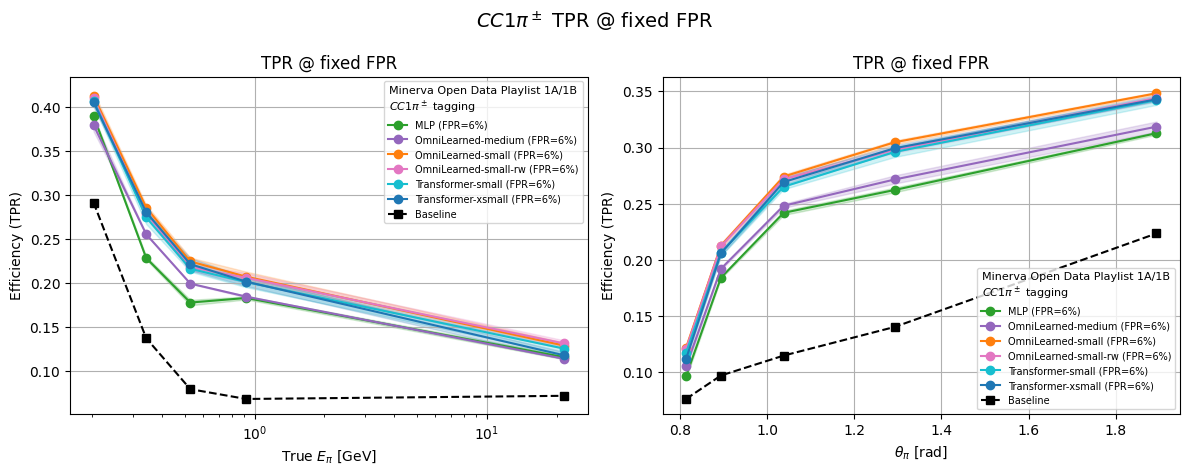

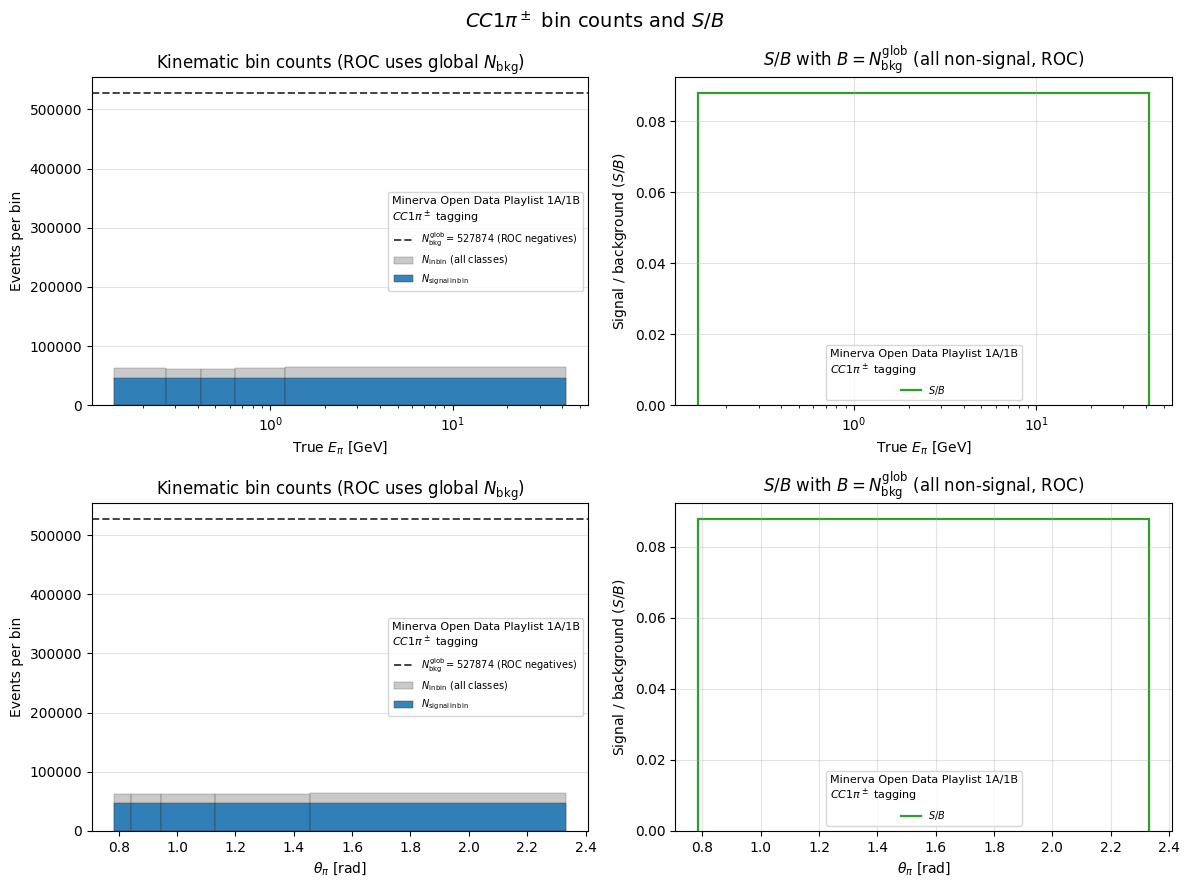

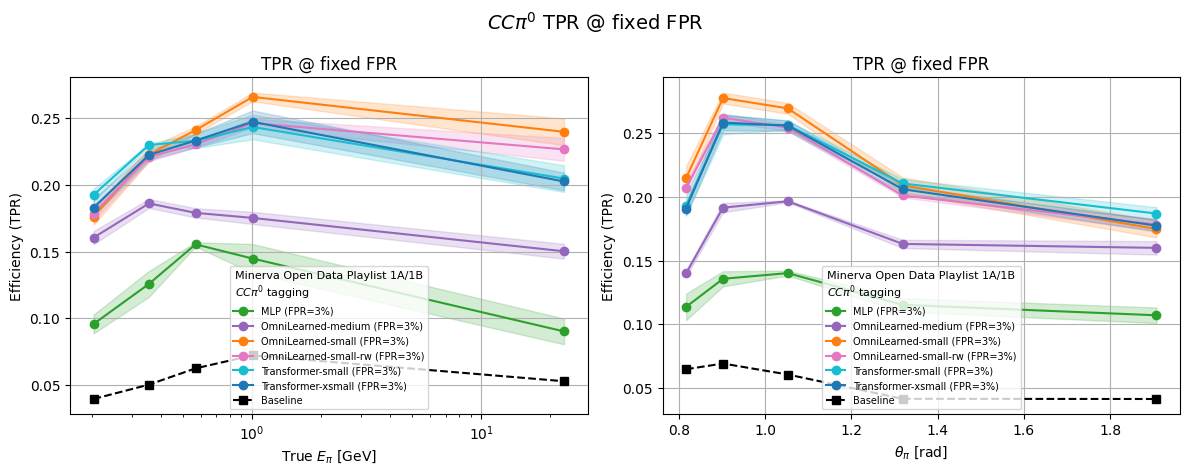

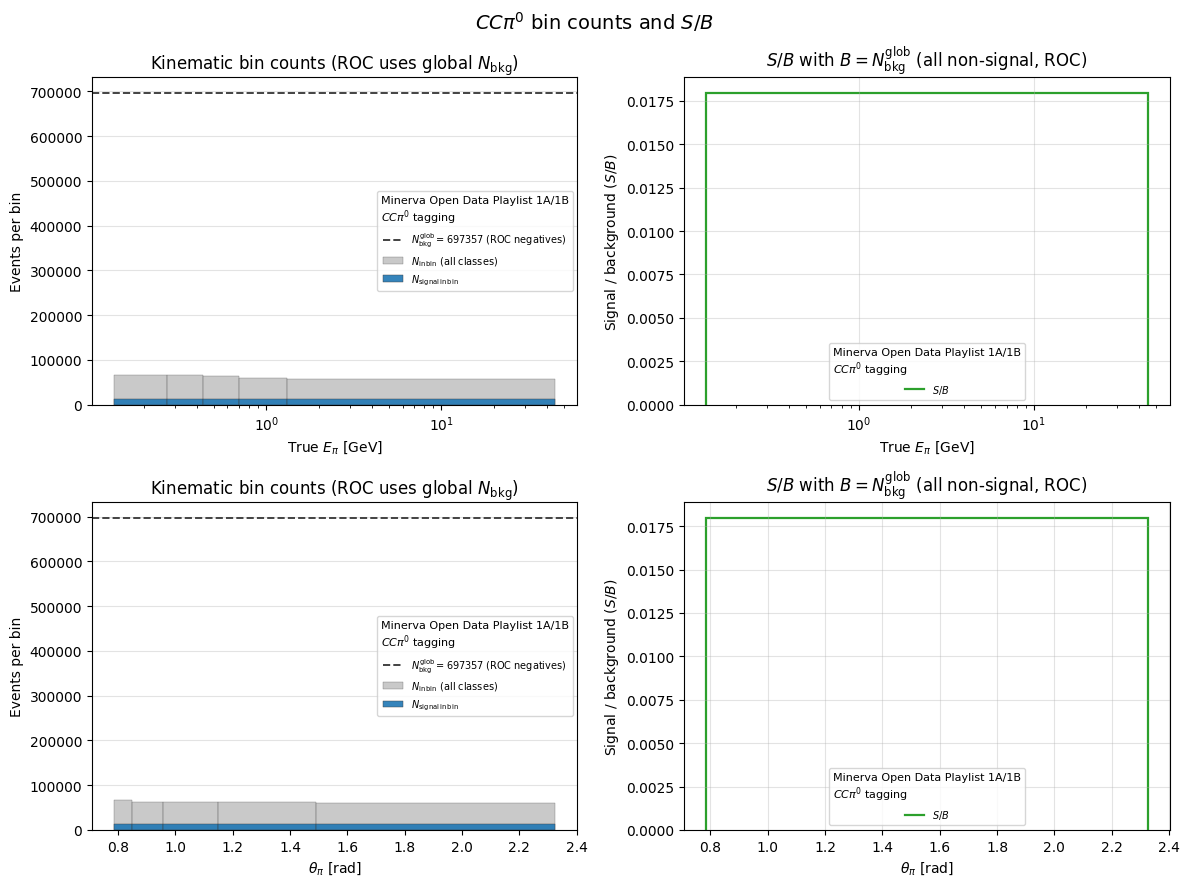

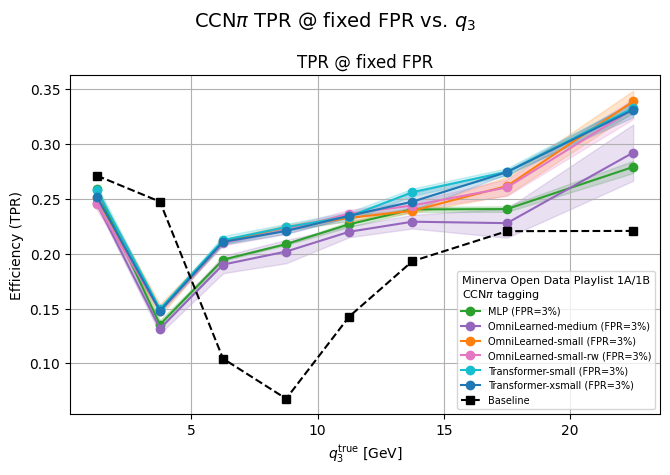

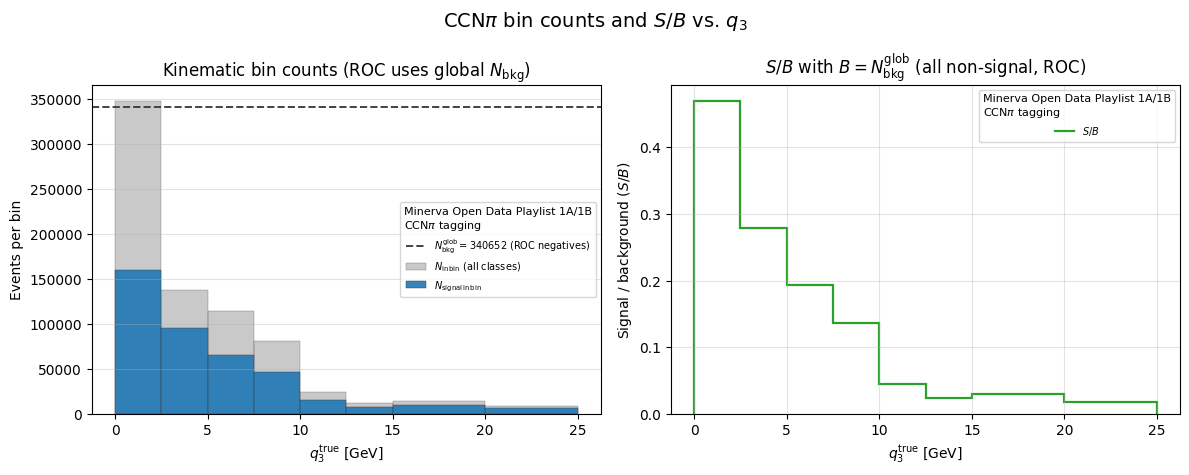

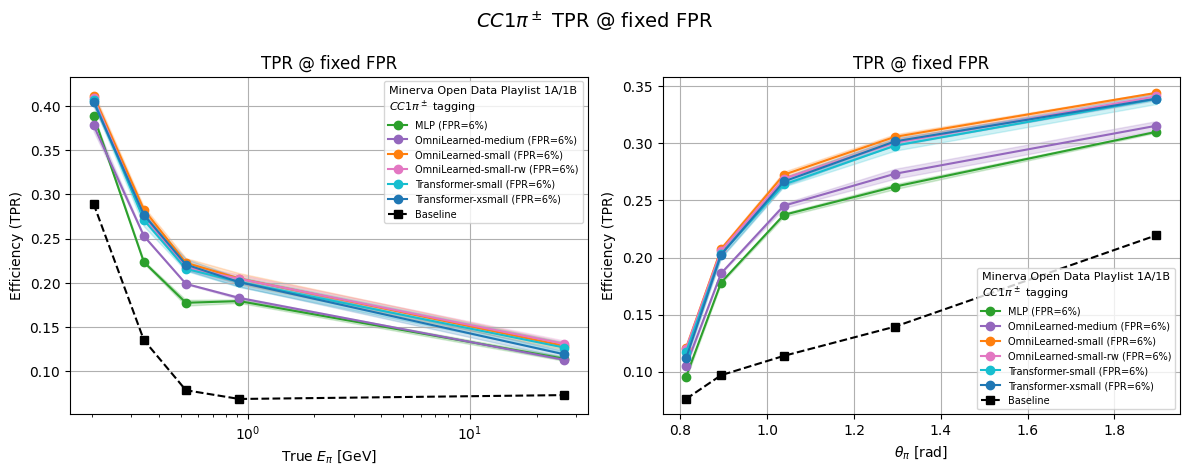

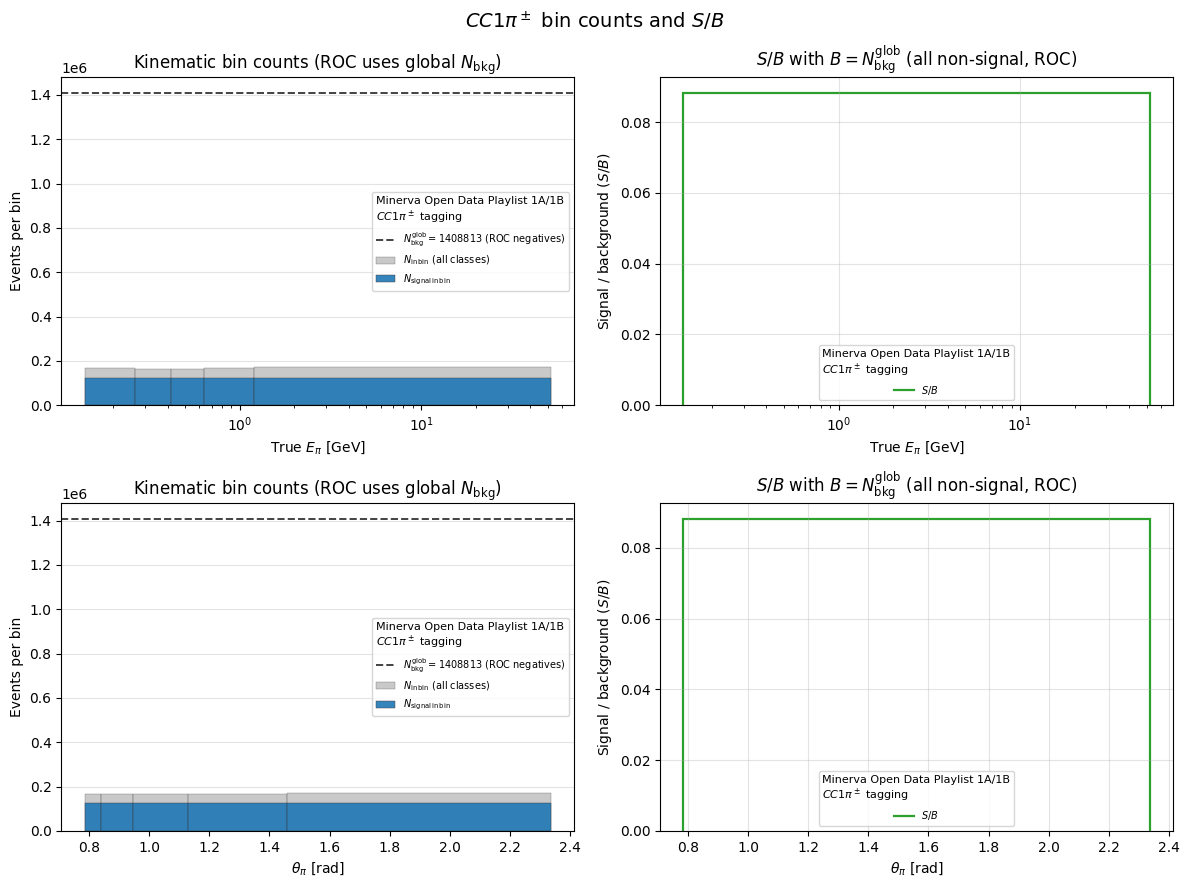

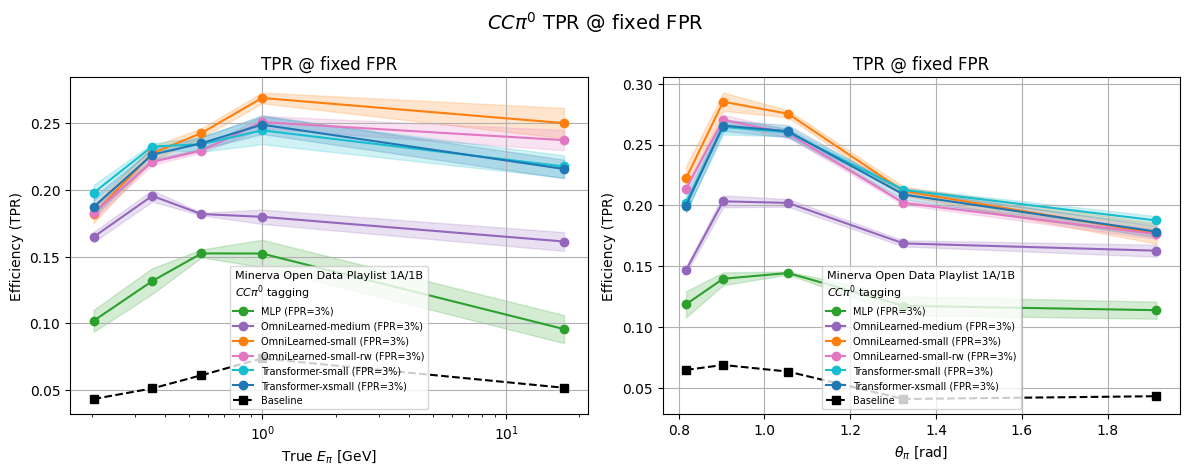

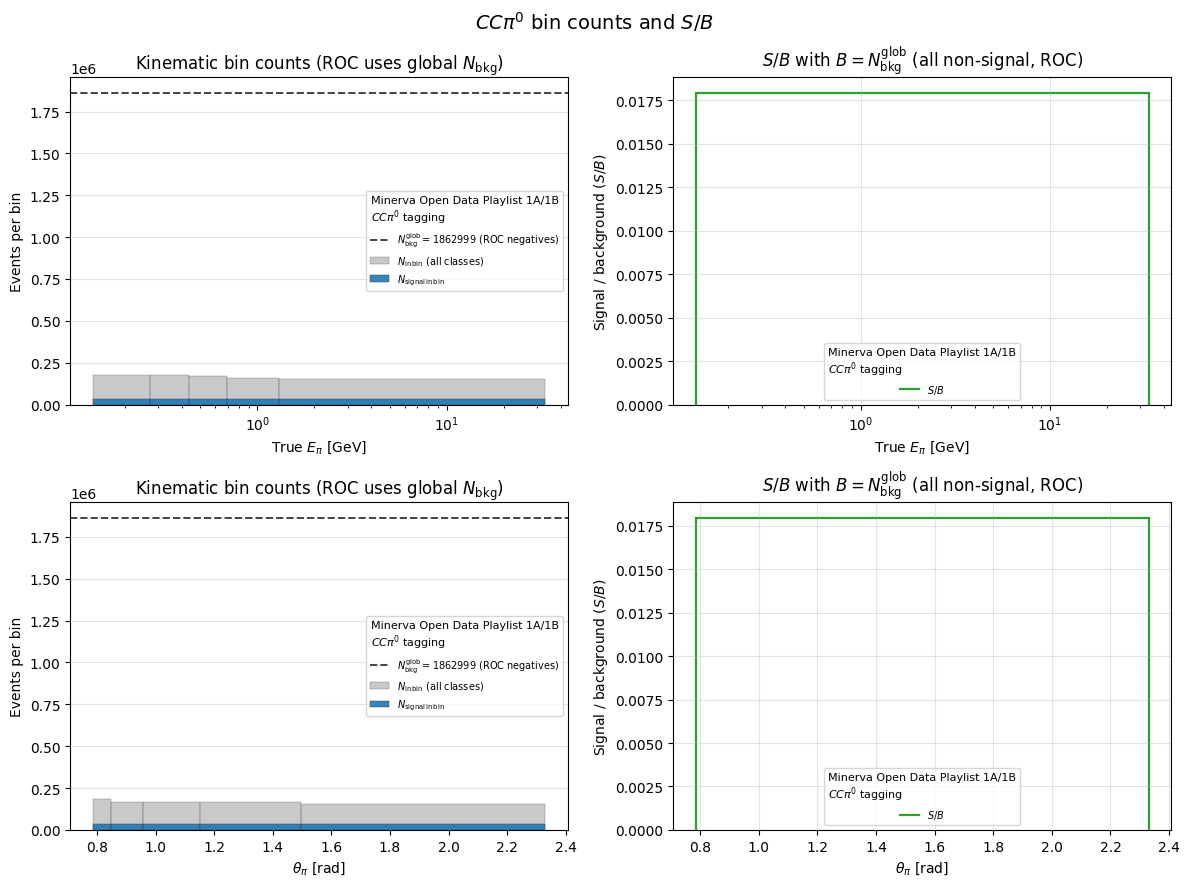

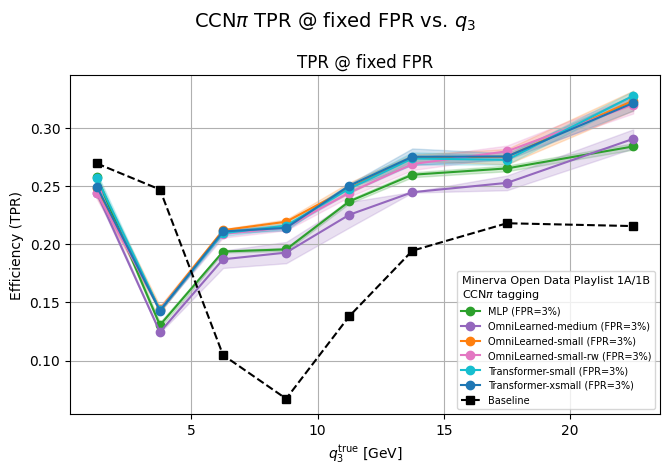

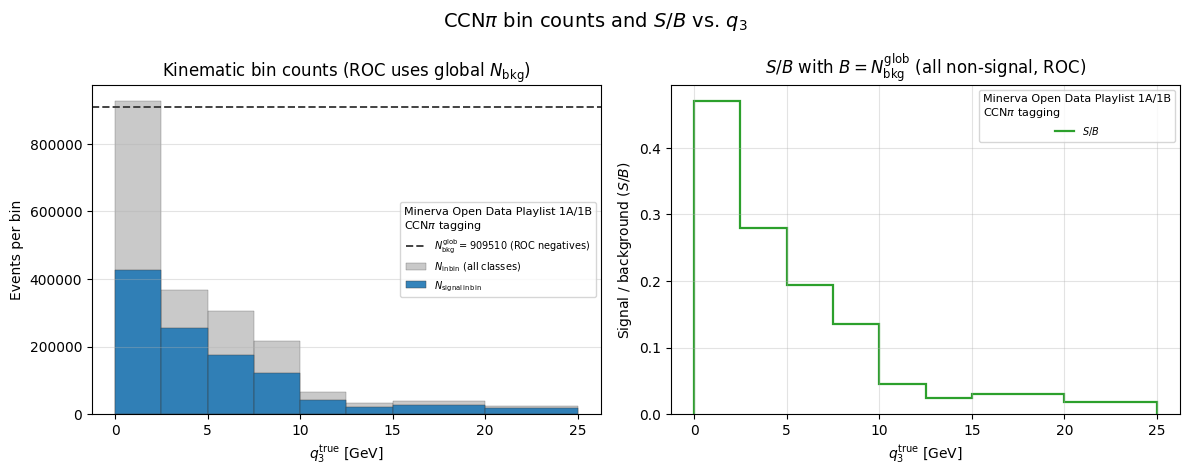

In [3]:
cc1pi_classes = [0]
cc1pi0_classes = [2]
multi_pi_classes = [0, 1]
PI0_MASS = 134.977  # MeV
DELTA_M = PI0_MASS

for playlist in PLAYLISTS:
    data = data_by_playlist[playlist]
    figs_tpr = []
    figs_counts = []

    test_idx = data["test_idx"][playlist]
    baselines_pl = data["baselines"][playlist]
    first_model = next(iter(results))
    run0 = results[first_model][0][playlist]
    pid = run0["pid"]

    # ----- CC1π± -----
    n_muons = baselines_pl["n_muons"][test_idx]
    n_charged_prongs = baselines_pl["n_charged_prongs"][test_idx]
    improved_nmichel = baselines_pl["improved_nmichel"][test_idx]

    data_cc1pi = data_with_signal_pion_bins(
        data,
        pid,
        cc1pi_classes,
        pion_quantile_require_has_pion=False,
        pion_bin_edge_method="equal_frequency",
    )
    y_true_cc1pi = np.isin(pid, cc1pi_classes).astype(int)
    y_pred_cc1pi = (
        (n_muons == 1) & (n_charged_prongs == 1) & (improved_nmichel == 1)
    ).astype(int)

    tp = int(np.sum((y_pred_cc1pi == 1) & (y_true_cc1pi == 1)))
    fp = int(np.sum((y_pred_cc1pi == 1) & (y_true_cc1pi == 0)))
    fn = int(np.sum((y_pred_cc1pi == 0) & (y_true_cc1pi == 1)))
    tn = int(np.sum((y_pred_cc1pi == 0) & (y_true_cc1pi == 0)))
    baseline_fpr_cc1pi = fp / (fp + tn) if (fp + tn) > 0 else float("nan")

    print(f"N of CC1pi events: {int((y_true_cc1pi == 1).sum())}")
    print(f"[{playlist}] CC1π± baseline FPR={baseline_fpr_cc1pi:.4f}")

    metrics_cc1pi = compute_all_metrics(
        results,
        data_cc1pi,
        signal_classes=cc1pi_classes,
        fixed_fpr=[baseline_fpr_cc1pi],
        playlist=playlist,
        pion_bins_require_has_pion=False,
    )

    is_signal_cc1pi = y_true_cc1pi == 1
    reco_baseline_tpr_cc1pi = {
        "E": compute_reco_baseline_recall_per_bin(
            y_pred_cc1pi,
            is_signal_cc1pi,
            data_cc1pi["pion_E_MC"],
            data_cc1pi["pion_E_MC_bins"],
            has_pion=None,
        ),
        "theta": compute_reco_baseline_recall_per_bin(
            y_pred_cc1pi,
            is_signal_cc1pi,
            data_cc1pi["pion_theta_MC"],
            data_cc1pi["pion_theta_MC_bins"],
            has_pion=None,
            finite_bin_var=True,
        ),
    }

    x_E = data_cc1pi["pion_E_MC_bins_mid"]
    x_th = data_cc1pi["pion_theta_MC_bins_mid"]
    n_bg_cc1pi = int((y_true_cc1pi == 0).sum())

    figs_tpr.append(
        plot_tpr_fixed_fpr_two_panel(
            metrics_cc1pi,
            x_E,
            x_th,
            "E",
            "theta",
            [baseline_fpr_cc1pi],
            r"True $E_\pi$ [GeV]",
            r"$\theta_\pi$ [rad]",
            reco_baseline_tpr_cc1pi,
            "Baseline",
            title=r"$CC1\pi^\pm$ TPR @ fixed FPR",
            playlist=playlist,
            task_legend_line2=r"$CC1\pi^\pm$ tagging",
            log_x_left=True,
            colors=clrs_dict_full,
        )
    )

    n_tot_E, n_sig_E = per_bin_total_and_signal(
        is_signal_cc1pi,
        data_cc1pi["pion_E_MC"],
        data_cc1pi["pion_E_MC_bins"],
        has_pion=None,
    )
    n_tot_th, n_sig_th = per_bin_total_and_signal(
        is_signal_cc1pi,
        data_cc1pi["pion_theta_MC"],
        data_cc1pi["pion_theta_MC_bins"],
        has_pion=None,
        require_finite_bin_var=True,
    )
    figs_counts.append(
        plot_counts_sb_two_panel(
            data_cc1pi["pion_E_MC_bins"],
            data_cc1pi["pion_theta_MC_bins"],
            (n_tot_E, n_sig_E),
            (n_tot_th, n_sig_th),
            r"True $E_\pi$ [GeV]",
            r"$\theta_\pi$ [rad]",
            title=r"$CC1\pi^\pm$ bin counts and $S/B$",
            playlist=playlist,
            task_legend_line2=r"$CC1\pi^\pm$ tagging",
            log_x_left=True,
            n_bg_global=n_bg_cc1pi,
        )
    )

    # ----- CCπ0 -----
    is_pizero_signal = baselines_pl["is_pizero_signal"][test_idx]
    two_gamma_inv_mass = baselines_pl["two_gamma_invariant_mass"][test_idx]
    n_michel = baselines_pl["improved_nmichel"][test_idx]

    data_pi0 = data_with_signal_pion_bins(
        data,
        pid,
        cc1pi0_classes,
        pion_quantile_require_has_pion=False,
        pion_bin_edge_method="equal_frequency",
    )
    y_true_pi0 = np.isin(pid, cc1pi0_classes).astype(int)
    y_pred_pi0 = (
        (n_muons == 1)
        & (is_pizero_signal == 2)
        & (np.abs(two_gamma_inv_mass - PI0_MASS) < DELTA_M)
        & (n_michel == 0)
    ).astype(int)

    tp0 = int(np.sum((y_pred_pi0 == 1) & (y_true_pi0 == 1)))
    fp0 = int(np.sum((y_pred_pi0 == 1) & (y_true_pi0 == 0)))
    tn0 = int(np.sum((y_pred_pi0 == 0) & (y_true_pi0 == 0)))
    baseline_fpr_pi0 = fp0 / (fp0 + tn0) if (fp0 + tn0) > 0 else float("nan")

    print(f"[{playlist}] CC1π0 baseline FPR={baseline_fpr_pi0:.4f}")

    metrics_pi0 = compute_all_metrics(
        results,
        data_pi0,
        signal_classes=cc1pi0_classes,
        fixed_fpr=[baseline_fpr_pi0],
        playlist=playlist,
        pion_bins_require_has_pion=False,
    )

    is_signal_pi0 = y_true_pi0 == 1
    reco_baseline_tpr_pi0 = {
        "E": compute_reco_baseline_recall_per_bin(
            y_pred_pi0,
            is_signal_pi0,
            data_pi0["pion_E_MC"],
            data_pi0["pion_E_MC_bins"],
            has_pion=None,
        ),
        "theta": compute_reco_baseline_recall_per_bin(
            y_pred_pi0,
            is_signal_pi0,
            data_pi0["pion_theta_MC"],
            data_pi0["pion_theta_MC_bins"],
            has_pion=None,
            finite_bin_var=True,
        ),
    }

    x_E0 = data_pi0["pion_E_MC_bins_mid"]
    x_th0 = data_pi0["pion_theta_MC_bins_mid"]
    n_bg_pi0 = int((y_true_pi0 == 0).sum())

    figs_tpr.append(
        plot_tpr_fixed_fpr_two_panel(
            metrics_pi0,
            x_E0,
            x_th0,
            "E",
            "theta",
            [baseline_fpr_pi0],
            r"True $E_\pi$ [GeV]",
            r"$\theta_\pi$ [rad]",
            reco_baseline_tpr_pi0,
            "Baseline",
            title=r"$CC\pi^0$ TPR @ fixed FPR",
            playlist=playlist,
            task_legend_line2=r"$CC\pi^0$ tagging",
            log_x_left=True,
            colors=clrs_dict_full,
        )
    )

    n_tot_E0, n_sig_E0 = per_bin_total_and_signal(
        is_signal_pi0,
        data_pi0["pion_E_MC"],
        data_pi0["pion_E_MC_bins"],
        has_pion=None,
    )
    n_tot_th0, n_sig_th0 = per_bin_total_and_signal(
        is_signal_pi0,
        data_pi0["pion_theta_MC"],
        data_pi0["pion_theta_MC_bins"],
        has_pion=None,
        require_finite_bin_var=True,
    )
    figs_counts.append(
        plot_counts_sb_two_panel(
            data_pi0["pion_E_MC_bins"],
            data_pi0["pion_theta_MC_bins"],
            (n_tot_E0, n_sig_E0),
            (n_tot_th0, n_sig_th0),
            r"True $E_\pi$ [GeV]",
            r"$\theta_\pi$ [rad]",
            title=r"$CC\pi^0$ bin counts and $S/B$",
            playlist=playlist,
            task_legend_line2=r"$CC\pi^0$ tagging",
            log_x_left=True,
            n_bg_global=n_bg_pi0,
        )
    )

    # ----- CCNπ (q3) -----
    y_true_ccnpi = np.isin(pid, multi_pi_classes).astype(int)
    y_pred_ccnpi = (
        (n_muons == 1) & (n_charged_prongs >= 1) & (improved_nmichel >= 1)
    ).astype(int)

    tpn = int(np.sum((y_pred_ccnpi == 1) & (y_true_ccnpi == 1)))
    fpn = int(np.sum((y_pred_ccnpi == 1) & (y_true_ccnpi == 0)))
    tnn = int(np.sum((y_pred_ccnpi == 0) & (y_true_ccnpi == 0)))
    baseline_fpr_ccnpi = fpn / (fpn + tnn) if (fpn + tnn) > 0 else float("nan")

    print(f"[{playlist}] CCNπ baseline FPR={baseline_fpr_ccnpi:.4f}")

    metrics_q3 = compute_all_metrics_q3(
        results,
        data,
        signal_classes=multi_pi_classes,
        fixed_fpr=[baseline_fpr_ccnpi],
        playlist=playlist,
    )

    is_signal_ccnpi = y_true_ccnpi == 1
    reco_baseline_tpr_q3 = compute_reco_baseline_recall_per_bin(
        y_pred_ccnpi,
        is_signal_ccnpi,
        data["q3_GeV"],
        data["q3_bin_edges"],
    )

    x_q3 = data["q3_bin_mids"]
    n_bg_ccnpi = int((y_true_ccnpi == 0).sum())

    figs_tpr.append(
        plot_tpr_fixed_fpr_single_panel(
            metrics_q3,
            x_q3,
            [baseline_fpr_ccnpi],
            r"$q_{3}^{\mathrm{true}}$ [GeV]",
            reco_baseline_tpr_q3,
            "Baseline",
            title=r"CCN$\pi$ TPR @ fixed FPR vs. $q_3$",
            playlist=playlist,
            task_legend_line2=r"CCN$\pi$ tagging",
            colors=clrs_dict_full,
        )
    )

    n_tot_q3, n_sig_q3 = per_bin_total_and_signal(
        is_signal_ccnpi,
        data["q3_GeV"],
        data["q3_bin_edges"],
        has_pion=None,
    )
    figs_counts.append(
        plot_counts_sb_single_panel(
            data["q3_bin_edges"],
            (n_tot_q3, n_sig_q3),
            r"$q_{3}^{\mathrm{true}}$ [GeV]",
            title=r"CCN$\pi$ bin counts and $S/B$ vs. $q_3$",
            playlist=playlist,
            task_legend_line2=r"CCN$\pi$ tagging",
            n_bg_global=n_bg_ccnpi,
        )
    )

    out_tpr = OUTPUT_DIR / f"eval_classification_light_tpr_fixed_fpr_{playlist}.pdf"
    out_ct = OUTPUT_DIR / f"eval_classification_light_counts_sb_{playlist}.pdf"
    save_figures_to_pdf(figs_tpr, out_tpr)
    save_figures_to_pdf(figs_counts, out_ct)
    print(f"Saved: {out_tpr}")
    print(f"Saved: {out_ct}")
